In [51]:
# Trader Performance vs Market Sentiment Analysis

## Objective
# To analyze how market sentiment (Fear/Greed) affects trader behavior and performance using Hyperliquid trading data.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sentiment = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\power bi\\data science ]\\fear_greed_index.csv")
trades = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\power bi\\data science ]\\historical_data (1).csv")

print(sentiment.head())
print(trades.head())


    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [ ]:
print(sentiment.shape)#fear_greed_index
print(trades.shape)

print(sentiment.isnull().sum())
print(trades.isnull().sum())

print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

(2644, 4)
(211224, 16)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0
0


In [8]:

# Convert trades timestamp
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [17]:

# Merge
df = pd.merge(trades, sentiment, on='date', how='left')
print(df)
print(df.columns)
print(len(df.columns))

                                           Account      Coin  Execution Price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9874   
4       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9894   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   

        Size Tokens  Size U

In [16]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print(merged.head())
print(len(merged.columns))

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

In [ ]:
print(df.info())
print(df.describe())
print(df.head(5))

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  datetime64[us]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

In [49]:
print(df["Side"].value_counts())
print(df["classification"].value_counts())

summary_side = df.groupby("Side").agg(
    Total_PnL=("Closed PnL", "sum"),
    Avg_PnL=("Closed PnL", "mean"),
    Trades=("Closed PnL", "count")
)

print(summary_side)

Side
SELL    108528
BUY     102696
Name: count, dtype: int64
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64
         Total_PnL    Avg_PnL  Trades
Side                                 
BUY   3.707811e+06  36.104730  102696
SELL  6.589148e+06  60.713803  108528


In [66]:
trader_pnl = df.groupby("Account")["Closed PnL"].mean()

print(trader_pnl.sort_values(ascending=False).head(10))

Account
0x420ab45e0bd8863569a5efbb9c05d91f40624641    520.902331
0x083384f897ee0f19899168e3b1bec365f52a9012    419.127768
0x430f09841d65beb3f27765503d0f850b8bce7713    336.735548
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    281.826227
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    270.034947
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0    174.691809
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    161.133275
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    155.589314
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    145.481748
0xae5eacaf9c6b9111fd53034a602c192a04e082ed    120.507317
Name: Closed PnL, dtype: float64


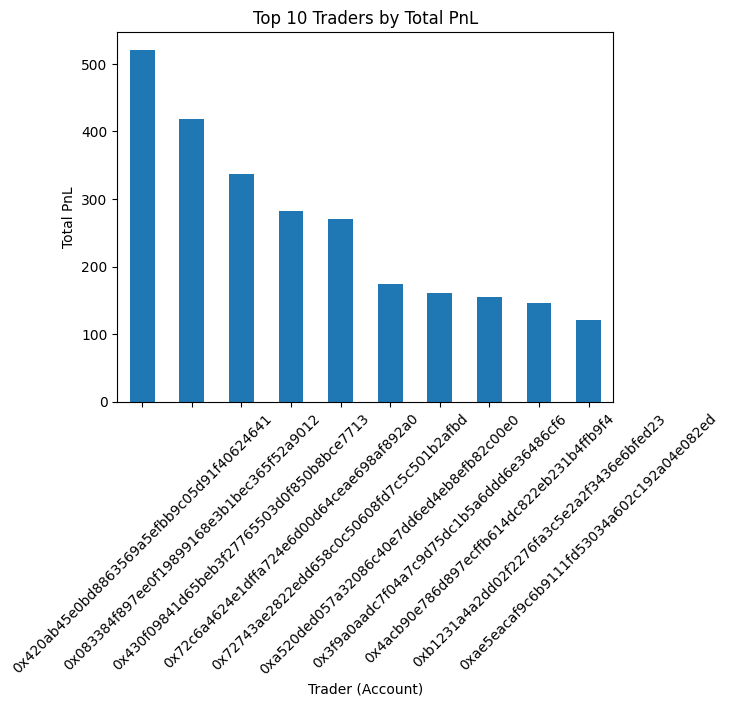

In [65]:
trader_pnl = df.groupby("Account")["Closed PnL"].mean()

trader_pnl.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Traders by Total PnL")
plt.xlabel("Trader (Account)")
plt.ylabel("Total PnL")

plt.xticks(rotation=45)
plt.show()

In [68]:
bottom10 = trader_pnl.sort_values().head(10)
print(bottom10)

Account
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   -38.286626
0x8170715b3b381dffb7062c0298972d4727a0a63b   -36.431455
0x271b280974205ca63b716753467d5a371de622ab   -18.492043
0x8477e447846c758f5a675856001ea72298fd9cb5     2.928191
0x39cef799f8b69da1995852eea189df24eb5cae3c     4.028119
0xb899e522b5715391ae1d4f137653e7906c5e2115     4.648305
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     6.577654
0xa0feb3725a9335f49874d7cd8eaad6be45b27416     6.812104
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     9.557693
0x28736f43f1e871e6aa8b1148d38d4994275d72c4     9.951530
Name: Closed PnL, dtype: float64


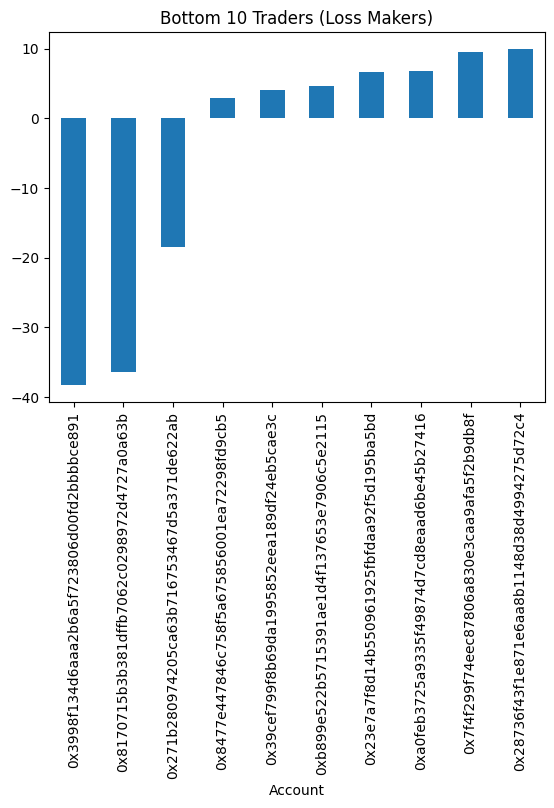

In [67]:
bottom10 = trader_pnl.sort_values().head(10)

bottom10.plot(kind='bar')
plt.title("Bottom 10 Traders (Loss Makers)")
plt.show()

In [61]:
trade_count = df.groupby('classification').size()
print(trade_count)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


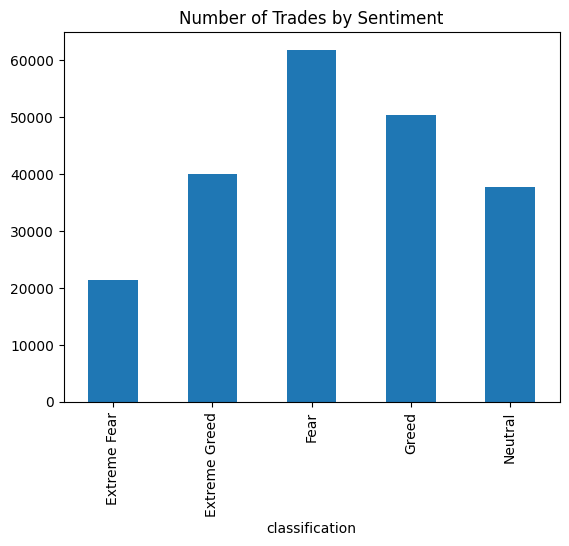

In [62]:
df.groupby('classification').size().plot(kind='bar')
plt.title("Number of Trades by Sentiment")
plt.show()

In [33]:
pnl_sentiment = df.groupby('classification')['Closed PnL'].mean()
print(pnl_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


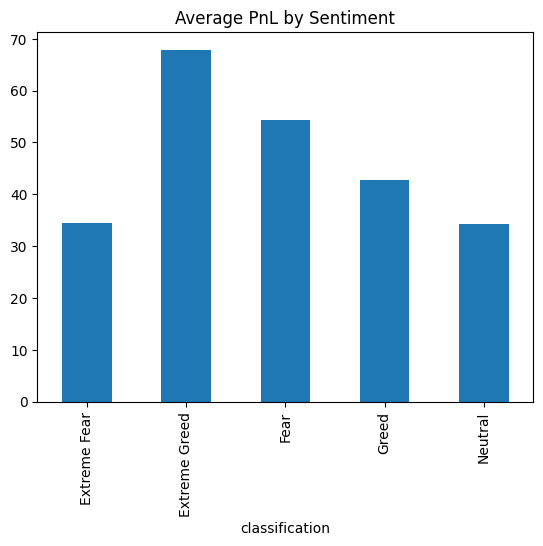

In [60]:
pnl_sentiment = df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.show()

In [35]:
df['win'] = df['Closed PnL'] > 0

win_rate = df.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


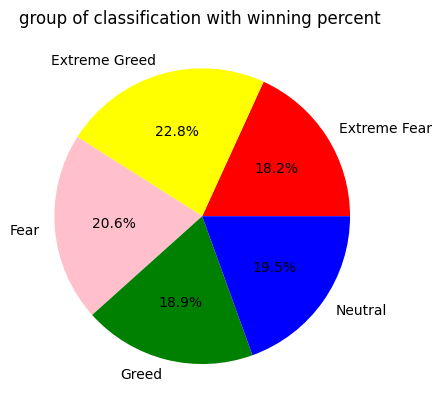

In [73]:
win_rate = df.groupby('classification')['win'].mean()
plt.title("group of classification with winning percent ")
plt.pie(win_rate,labels=win_rate.index,autopct="%1.1f%%",colors=["red","yellow","pink","green","blue"])#label  pie ki per seace ki valy

plt.grid("-")
plt.show()

In [58]:
avg_size = df.groupby("classification")["Size USD"].mean()
print(avg_size)
avg_size_with_buy_sale = df.groupby(["classification","Side"])["Size USD"].mean()
print(avg_size_with_buy_sale)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64
classification  Side
Extreme Fear    BUY     5161.502485
                SELL    5546.414885
Extreme Greed   BUY     3363.034672
                SELL    2908.231569
Fear            BUY     8154.666208
                SELL    7491.463987
Greed           BUY     6306.490894
                SELL    5192.761477
Neutral         BUY     3881.410441
                SELL    5696.190011
Name: Size USD, dtype: float64


In [39]:
long_short = df.groupby(['classification','Side']).size()
print(long_short)

classification  Side
Extreme Fear    BUY     10935
                SELL    10465
Extreme Greed   BUY     17940
                SELL    22052
Fear            BUY     30270
                SELL    31567
Greed           BUY     24576
                SELL    25727
Neutral         BUY     18969
                SELL    18717
dtype: int64


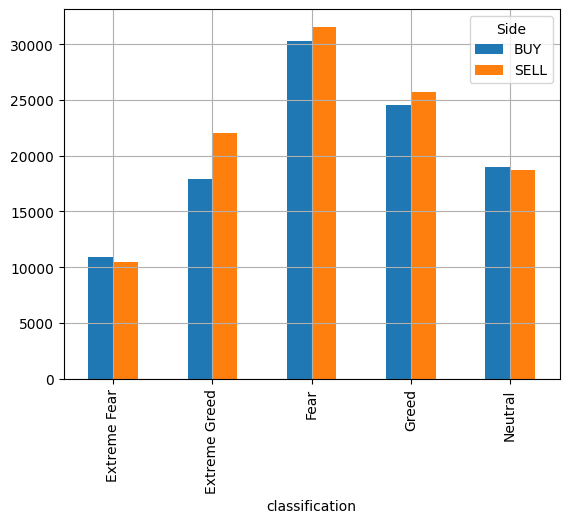

In [75]:
long_short = df.groupby(['classification','Side']).size().unstack().plot(kind="bar")
plt.grid()
plt.show()


In [41]:
combo = df.groupby(['classification','Side'])['Closed PnL'].mean()
print(combo)

classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64
